# ARIMA Time Series Modelling
### Goal: Understand and build ARIMA models to forecast time series data

---

This notebook continues from the Feature Engineering notebook.  
We now move into **modelling** — using a statistical method called ARIMA to make forecasts.

### What is ARIMA?

ARIMA stands for **AutoRegressive Integrated Moving Average**.  
It is a classic statistical method for predicting future values in a time series.

### What we will do in this notebook

1. Install and import libraries
2. Load the Airline Passengers dataset
3. Explore and visualise the data
4. Decompose the series into trend, seasonality, and noise
5. Check for stationarity (a requirement for ARIMA)
6. Read ACF and PACF plots to choose ARIMA parameters
7. Build and fit a SARIMAX model
8. Evaluate how well the model predicts

---

> **Dataset used:** The classic Airline Passengers dataset (1949–1960).  
> It records monthly passenger counts and has a clear upward trend with seasonal peaks every summer.

---
## Step 1 — Install Libraries

In [ ]:
# Run this cell first to install the libraries we need
# The exclamation mark (!) tells the notebook to run a terminal command

!pip install pandas numpy matplotlib statsmodels scikit-learn seaborn

---
## Step 2 — Import Libraries

We import tools for data handling, visualisation, and building the ARIMA model.

In [ ]:
# pandas — for working with tables of data
import pandas as pd

# numpy — for numerical calculations
import numpy as np

# matplotlib — for drawing charts
import matplotlib.pyplot as plt

# seaborn — makes charts look nicer
import seaborn as sns

# statsmodels — contains all the ARIMA/time series tools we need
from statsmodels.tsa.stattools import adfuller         # Stationarity test
from statsmodels.tsa.seasonal import seasonal_decompose # Break series into components
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # ACF and PACF plots
from statsmodels.tsa.statespace.sarimax import SARIMAX  # The ARIMA model

# scikit-learn — for measuring how accurate our predictions are
from sklearn.metrics import r2_score, mean_absolute_error

# Warnings — hide unimportant messages
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 3 — Load the Dataset

We are using the **Airline Passengers** dataset.  
It contains monthly passenger counts from January 1949 to December 1960.

This is a well-known dataset in time series analysis because it shows both:
- A clear **upward trend** (more people flying over the years)
- Clear **seasonality** (more passengers every summer)

In [ ]:
# Load the Airline Passengers dataset
# This dataset is hosted online — no CSV file needed

url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vTD-VBPkHgph0AWNSd0ZvAyJ098KmGmGjvWaNABAr2xFpArAW3-jv0ZeU2cmolDlFLUbWqHvsnXaWML/pub?gid=1463613835&single=true&output=csv'

df = pd.read_csv(url)

print("Dataset loaded!")
print("Number of rows:", len(df))
print("Columns:", list(df.columns))
print()
print("First 5 rows:")
print(df.head())

Dataset loaded!
Number of rows: 144
Columns: ['Month', 'Passengers']

First 5 rows:
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


---
## Step 4 — Prepare the Data

Before we can use ARIMA, we need to:
1. Convert the Month column from text to a proper date format
2. Set the date as the index (row label) of the table
3. Tell Python that our data is monthly

In [ ]:
# Step 4a: Convert the Month column from text to a date
# Right now it is stored as text like "1949-01" — we need Python to understand it as a date

df['Month'] = pd.to_datetime(df['Month'])

print("Month column converted to date format.")
print("Example value:", df['Month'][0])

Month column converted to date format.
Example value: 1949-01-01 00:00:00


In [ ]:
# Step 4b: Set the Month column as the index
# Time series models expect the dates to be the row labels (index), not a regular column

df = df.set_index('Month')

print("Month is now the index.")
print(df.head())

Month is now the index.
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


In [ ]:
# Step 4c: Tell Python the data is monthly (one row per month)
# This is required by ARIMA — it needs to know how often the data is collected

df.index = pd.DatetimeIndex(df.index.values, freq=df.index.inferred_freq)

print("Frequency set to:", df.index.freq)
print("Date range:", df.index.min(), "to", df.index.max())

Frequency set to: <MonthBegin>
Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00


---
## Step 5 — Explore and Visualise the Data

Always plot the data before modelling.  
This helps us spot trends, seasonal patterns, and unusual values.

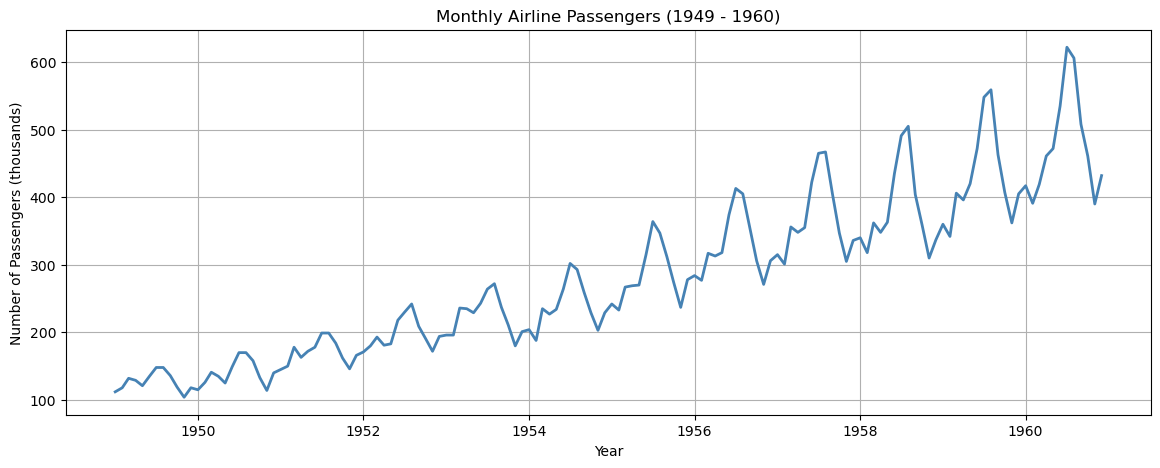

In [ ]:
# Plot the full time series

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Passengers'], color='steelblue', linewidth=2)
plt.title('Monthly Airline Passengers (1949 - 1960)')
plt.xlabel('Year')
plt.ylabel('Number of Passengers (thousands)')
plt.grid(True)
plt.show()

# What to look for:
# - The line goes upward overall — this is the TREND
# - Every year has a peak in the middle (summer) — this is SEASONALITY
# - The peaks get taller over time — the variation is growing

---
## Step 6 — Decompose the Time Series

A time series can be broken into three parts:

| Part | What it means |
|---|---|
| **Trend** | The long-term direction (going up, down, or flat) |
| **Seasonality** | A pattern that repeats at regular intervals (e.g. every 12 months) |
| **Residual** | What is left over after removing trend and seasonality (noise) |

Breaking the series apart helps us understand what is driving the data.  
We use a **multiplicative** model here because the seasonal peaks grow bigger over time.

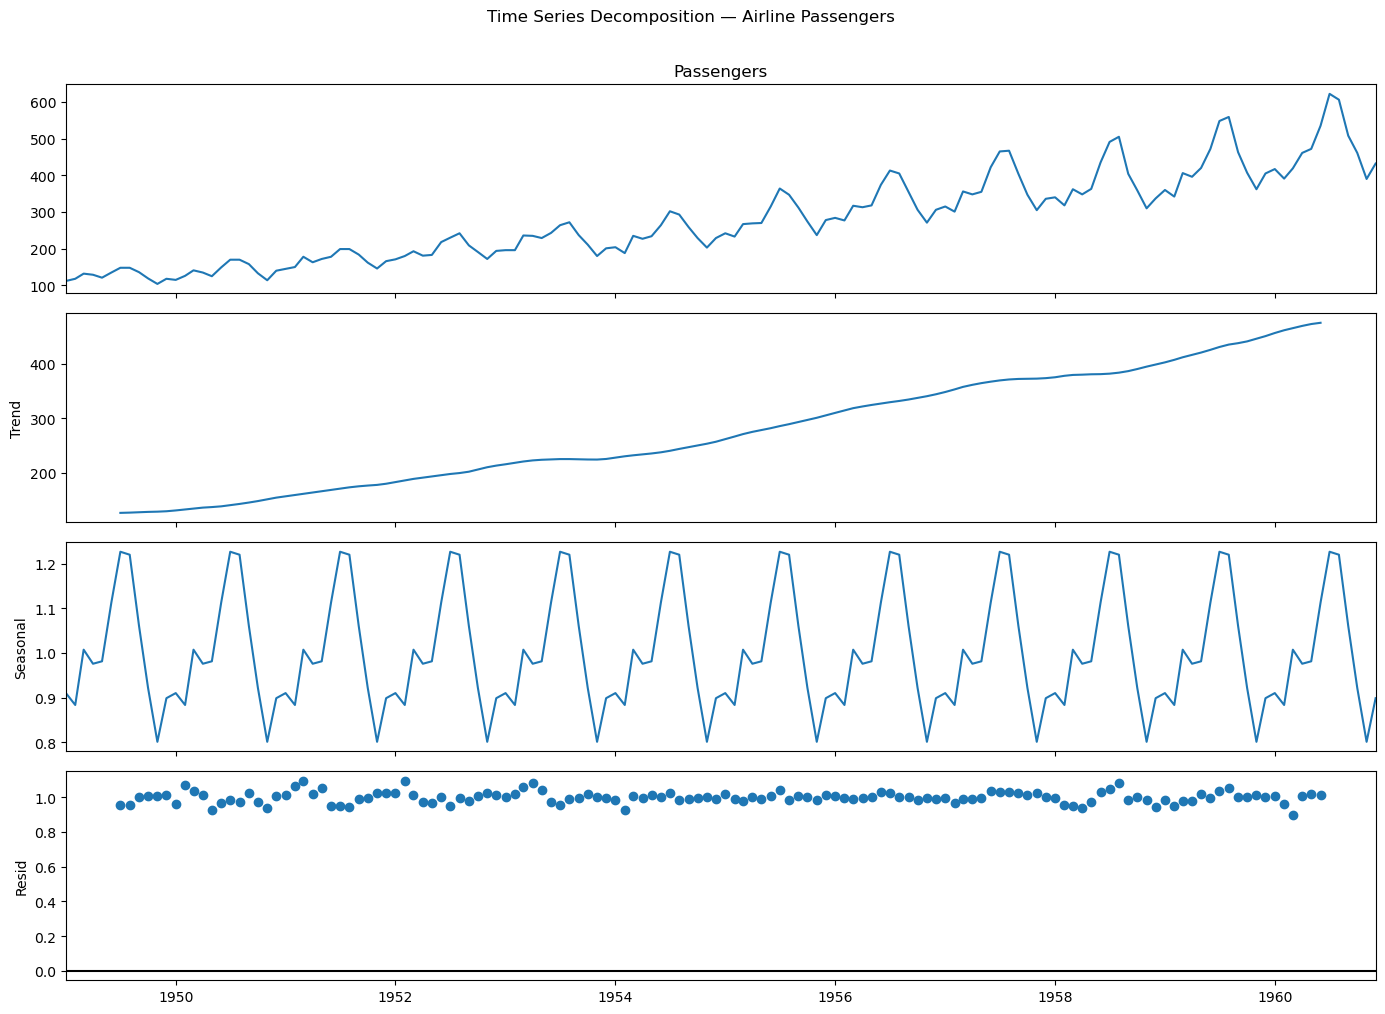

In [ ]:
# Decompose the time series into its three parts
# model='multiplicative' means the components multiply together (good when peaks grow over time)
# period=12 means we expect a pattern that repeats every 12 months (yearly)

decomposition = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

# Plot all four parts: original, trend, seasonality, and residual
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Time Series Decomposition — Airline Passengers', y=1.01)
plt.tight_layout()
plt.show()

# What to notice:
# - TREND: smooth upward line — passenger numbers grew steadily
# - SEASONAL: the same wave pattern repeats every 12 months
# - RESIDUAL: small random noise remaining after removing the above two

---
## Step 7 — Check for Stationarity

**What is stationarity?**  
A time series is "stationary" if its average and variability do not change over time.  
ARIMA requires the data to be stationary before it can model it.

We use the **Augmented Dickey-Fuller (ADF) test** to check this statistically.  
- If the p-value is **below 0.05** → the data IS stationary  
- If the p-value is **above 0.05** → the data is NOT stationary (we need to fix this)

In [ ]:
# Define a simple function to run the ADF stationarity test
# A function lets us reuse this test easily on different versions of the data

def check_stationarity(series, name):
    result = adfuller(series)
    p_value = result[1]

    print("ADF Test for:", name)
    print("  p-value:", round(p_value, 4))

    if p_value <= 0.05:
        print("  Result: Data IS stationary (good for ARIMA)")
    else:
        print("  Result: Data is NOT stationary — needs differencing")
    print()

In [ ]:
# Test the original data
check_stationarity(df['Passengers'], 'Original Passenger Data')

# Since the original data has a trend and growing variance,
# we expect it to NOT be stationary

ADF Test for: Original Passenger Data
  p-value: 0.9919
  Result: Data is NOT stationary — needs differencing



In [ ]:
# Fix stationarity using DIFFERENCING
# Differencing means: subtract yesterday's value from today's value
# This removes the trend by looking at CHANGES instead of raw values

# First differencing: removes the upward trend
df['diff_1'] = df['Passengers'].diff()

# Seasonal differencing: subtract the value from 12 months ago
# This removes the repeating yearly pattern
df['diff_seasonal'] = df['Passengers'].diff(12)

# Apply both: first difference AND seasonal difference
df['diff_1_seasonal'] = df['diff_1'].diff(12)

print("Differenced columns created.")
print(df[['Passengers', 'diff_1', 'diff_seasonal', 'diff_1_seasonal']].head(15))

Differenced columns created.
            Passengers  diff_1  diff_seasonal  diff_1_seasonal
1949-01-01         112     NaN            NaN              NaN
1949-02-01         118     6.0            NaN              NaN
1949-03-01         132    14.0            NaN              NaN
1949-04-01         129    -3.0            NaN              NaN
1949-05-01         121    -8.0            NaN              NaN
1949-06-01         135    14.0            NaN              NaN
1949-07-01         148    13.0            NaN              NaN
1949-08-01         148     0.0            NaN              NaN
1949-09-01         136   -12.0            NaN              NaN
1949-10-01         119   -17.0            NaN              NaN
1949-11-01         104   -15.0            NaN              NaN
1949-12-01         118    14.0            NaN              NaN
1950-01-01         115    -3.0            3.0              NaN
1950-02-01         126    11.0            8.0              5.0
1950-03-01         141    

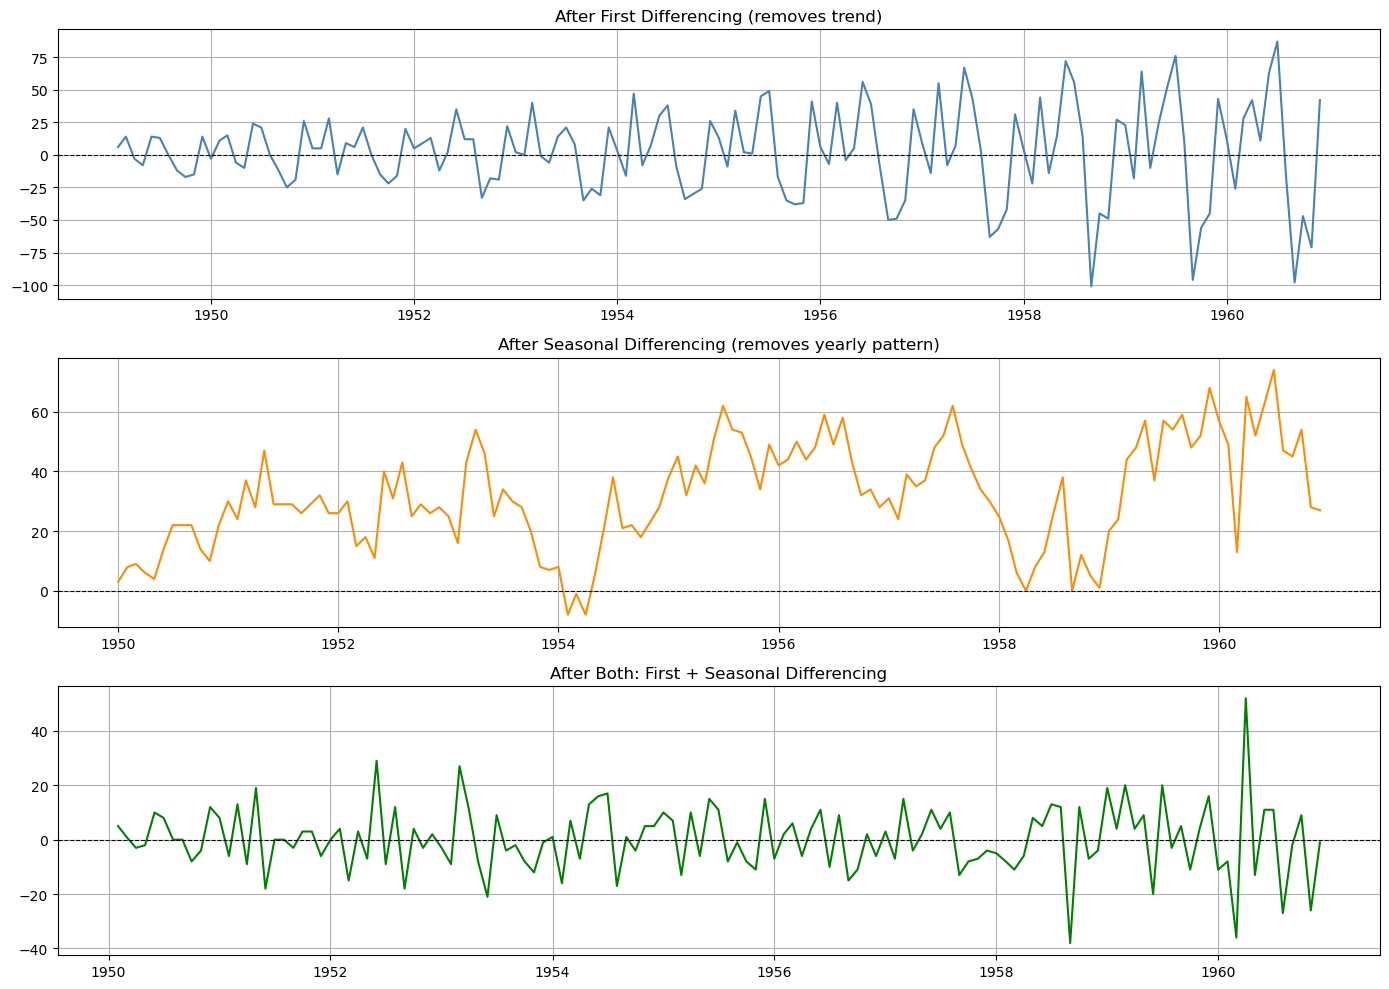

In [ ]:
# Plot the differenced series to see if it looks stable (flat / no trend)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df['diff_1'].dropna(), color='steelblue')
axes[0].set_title('After First Differencing (removes trend)')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].grid(True)

axes[1].plot(df['diff_seasonal'].dropna(), color='darkorange')
axes[1].set_title('After Seasonal Differencing (removes yearly pattern)')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].grid(True)

axes[2].plot(df['diff_1_seasonal'].dropna(), color='green')
axes[2].set_title('After Both: First + Seasonal Differencing')
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2].grid(True)

plt.tight_layout()
plt.show()

# A stationary series should look like random noise around zero — no trend, no growing peaks

In [ ]:
# Re-test stationarity after differencing

check_stationarity(df['diff_1'].dropna(), 'After First Differencing')
check_stationarity(df['diff_seasonal'].dropna(), 'After Seasonal Differencing')
check_stationarity(df['diff_1_seasonal'].dropna(), 'After First + Seasonal Differencing')

ADF Test for: After First Differencing
  p-value: 0.0542
  Result: Data is NOT stationary — needs differencing

ADF Test for: After Seasonal Differencing
  p-value: 0.0116
  Result: Data IS stationary (good for ARIMA)

ADF Test for: After First + Seasonal Differencing
  p-value: 0.0
  Result: Data IS stationary (good for ARIMA)



---
## Step 8 — Read ACF and PACF Plots

Before we can build an ARIMA model, we need to choose its parameters: **p**, **d**, and **q**.

These plots help us decide:

| Plot | Full name | Helps us choose |
|---|---|---|
| **ACF** | Autocorrelation Function | The **q** parameter (Moving Average order) |
| **PACF** | Partial Autocorrelation Function | The **p** parameter (AutoRegressive order) |

**How to read them:**  
- The x-axis shows "lags" — how many time steps back we are looking  
- The shaded blue area is the confidence zone  
- Bars that **stick out beyond the shaded area** are statistically significant  
- Count how many bars stick out before they all drop inside the shaded area — that is your parameter value

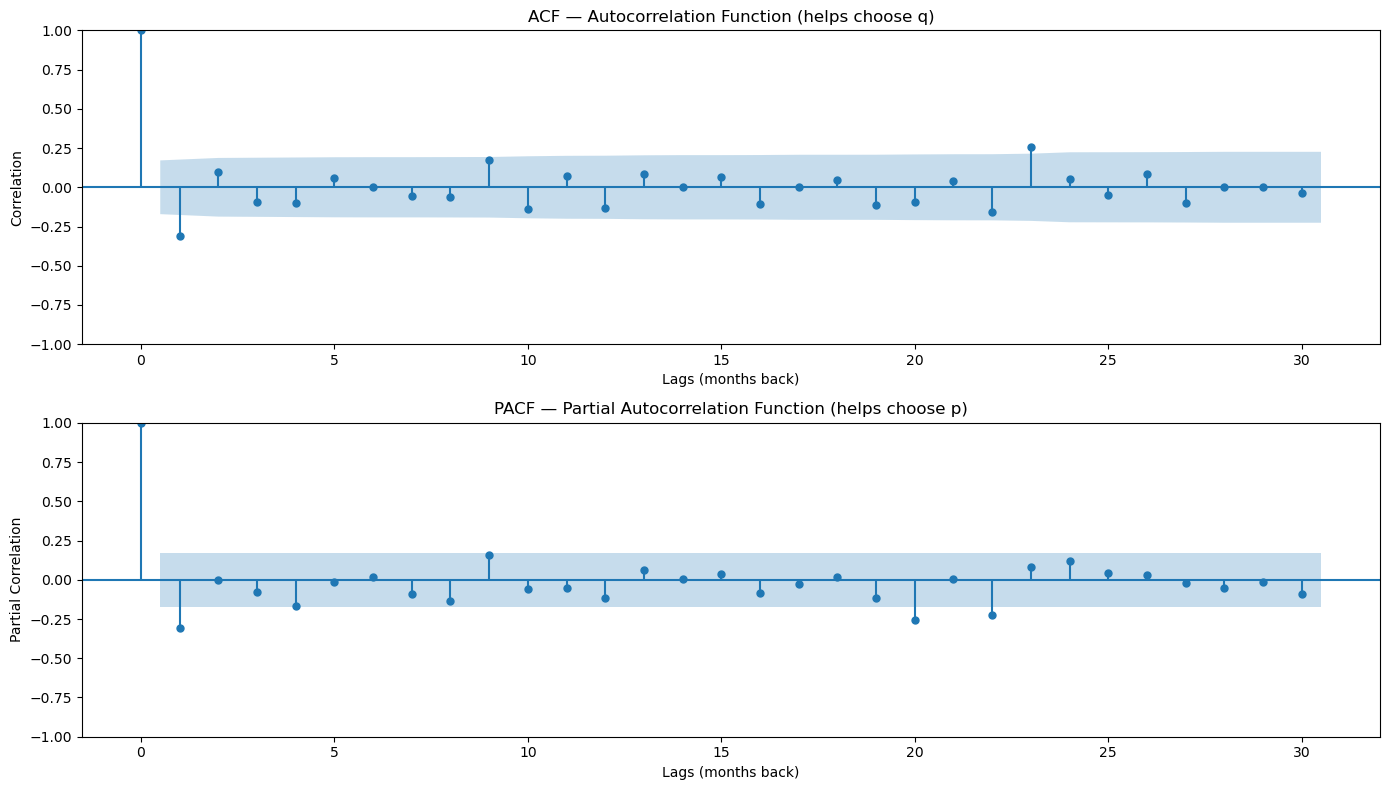

In [ ]:
# Plot ACF and PACF on the differenced (stationary) series
# We use the version after both first and seasonal differencing

series_for_acf = df['diff_1_seasonal'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ACF plot — helps choose q (Moving Average order)
plot_acf(series_for_acf, lags=30, ax=axes[0])
axes[0].set_title('ACF — Autocorrelation Function (helps choose q)')
axes[0].set_xlabel('Lags (months back)')
axes[0].set_ylabel('Correlation')

# PACF plot — helps choose p (AutoRegressive order)
plot_pacf(series_for_acf, lags=30, ax=axes[1])
axes[1].set_title('PACF — Partial Autocorrelation Function (helps choose p)')
axes[1].set_xlabel('Lags (months back)')
axes[1].set_ylabel('Partial Correlation')

plt.tight_layout()
plt.show()

# How to read:
# - Look at lag 1: if the ACF bar at lag 1 is significant → include q=1
# - Look at lag 1: if the PACF bar at lag 1 is significant → include p=1
# - Look at lag 12: if bars at lag 12 are significant → seasonal components needed

### What the plots tell us

Based on the ACF and PACF plots, we can determine the ARIMA parameters:

- **p = 1** — The PACF shows a significant bar at lag 1, then drops. This means 1 AR term.
- **d = 1** — We applied first differencing to remove the trend.
- **q = 0** — The ACF does not show a clear pattern that suggests MA terms.
- **Seasonal P = 0, D = 1, Q = 0, s = 12** — We applied seasonal differencing (lag 12).

This gives us the model: **SARIMAX(1, 1, 0)(0, 1, 0, 12)**

---
## Step 9 — Split Data into Training and Test Sets

Before building the model, we split the data:
- **Training set** — what the model learns from (older data)
- **Test set** — what we use to check if the model is accurate (newer data it has never seen)

For time series, we always split by **time** — never randomly.  
We use the last 12 months (the full year of 1960) as our test set.

In [ ]:
# Add a 'month' column (1 to 12) — we will use this to help the model understand seasonality
df['month'] = df.index.month

# Split: everything except the last 12 rows → training
#        the last 12 rows → test
train = df[:-12]
test  = df[-12:]

print("Training set:", len(train), "months")
print("  From:", train.index.min().strftime('%Y-%m'), "to", train.index.max().strftime('%Y-%m'))
print()
print("Test set:", len(test), "months")
print("  From:", test.index.min().strftime('%Y-%m'), "to", test.index.max().strftime('%Y-%m'))

Training set: 132 months
  From: 1949-01 to 1959-12

Test set: 12 months
  From: 1960-01 to 1960-12


---
## Step 10 — Build the SARIMAX Model

**SARIMAX** is an extended version of ARIMA that also handles:
- **Seasonal patterns** (S = Seasonal)
- **External variables** (X = eXogenous) — extra inputs like the month number

We set up the model with two groups of parameters:

**Non-seasonal order (p, d, q):**
- p = 1 → use 1 past value
- d = 1 → apply first differencing once
- q = 0 → no moving average terms

**Seasonal order (P, D, Q, s):**
- P = 0 → no seasonal AR
- D = 1 → apply seasonal differencing once (removes yearly pattern)
- Q = 0 → no seasonal MA
- s = 12 → the seasonal cycle repeats every 12 months

In [ ]:
# Set the ARIMA parameters
# Non-seasonal: (p=1, d=1, q=0)
order = (1, 1, 0)

# Seasonal: (P=0, D=1, Q=0, s=12)
seasonal_order = (0, 1, 0, 12)

print("Model parameters:")
print("  Non-seasonal order (p, d, q):", order)
print("    p=1: use 1 past value (AR term)")
print("    d=1: difference the data once to remove trend")
print("    q=0: no moving average term")
print()
print("  Seasonal order (P, D, Q, s):", seasonal_order)
print("    P=0: no seasonal AR")
print("    D=1: seasonal differencing to remove yearly pattern")
print("    Q=0: no seasonal MA")
print("    s=12: pattern repeats every 12 months")

Model parameters:
  Non-seasonal order (p, d, q): (1, 1, 0)
    p=1: use 1 past value (AR term)
    d=1: difference the data once to remove trend
    q=0: no moving average term

  Seasonal order (P, D, Q, s): (0, 1, 0, 12)
    P=0: no seasonal AR
    D=1: seasonal differencing to remove yearly pattern
    Q=0: no seasonal MA
    s=12: pattern repeats every 12 months


In [ ]:
# Create the SARIMAX model
# endog = the column we want to predict (Passengers)
# exog  = extra information to help the model (month number 1-12)

model = SARIMAX(
    train['Passengers'],
    order=order,
    seasonal_order=seasonal_order,
    exog=train['month']
)

print("Model created.")
print("Next step: fit (train) the model on the training data.")

Model created.
Next step: fit (train) the model on the training data.


---
## Step 11 — Fit (Train) the Model

Fitting the model means letting it learn the patterns from the training data.  
The model adjusts its internal numbers to best match the historical passenger counts.

In [ ]:
# Fit the model to the training data
# This may take a few seconds

print("Training the model — please wait...")

model_fit = model.fit()

print("Model training complete!")
print()

# Show the model summary
# This table contains all the technical details of what the model learned
# The most important things to look at are:
# - The coefficients (weights) for each term
# - AIC and BIC scores (lower = better fit)
print(model_fit.summary())

Training the model — please wait...
Model training complete!

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  132
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood                -447.951
Date:                            Mon, 20 Apr 2026   AIC                            901.902
Time:                                    04:41:34   BIC                            910.239
Sample:                                01-01-1949   HQIC                           905.287
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month      -2.305e-05   3.55e+04  -6.49e-10      1.0

---
## Step 12 — Check the Residuals

**Residuals** are the errors the model made during training — the difference between what it predicted and what actually happened.

A good model has residuals that look like **random noise**:
- No patterns remaining
- Centred around zero
- No large spikes

If we still see patterns in the residuals, the model has missed something.

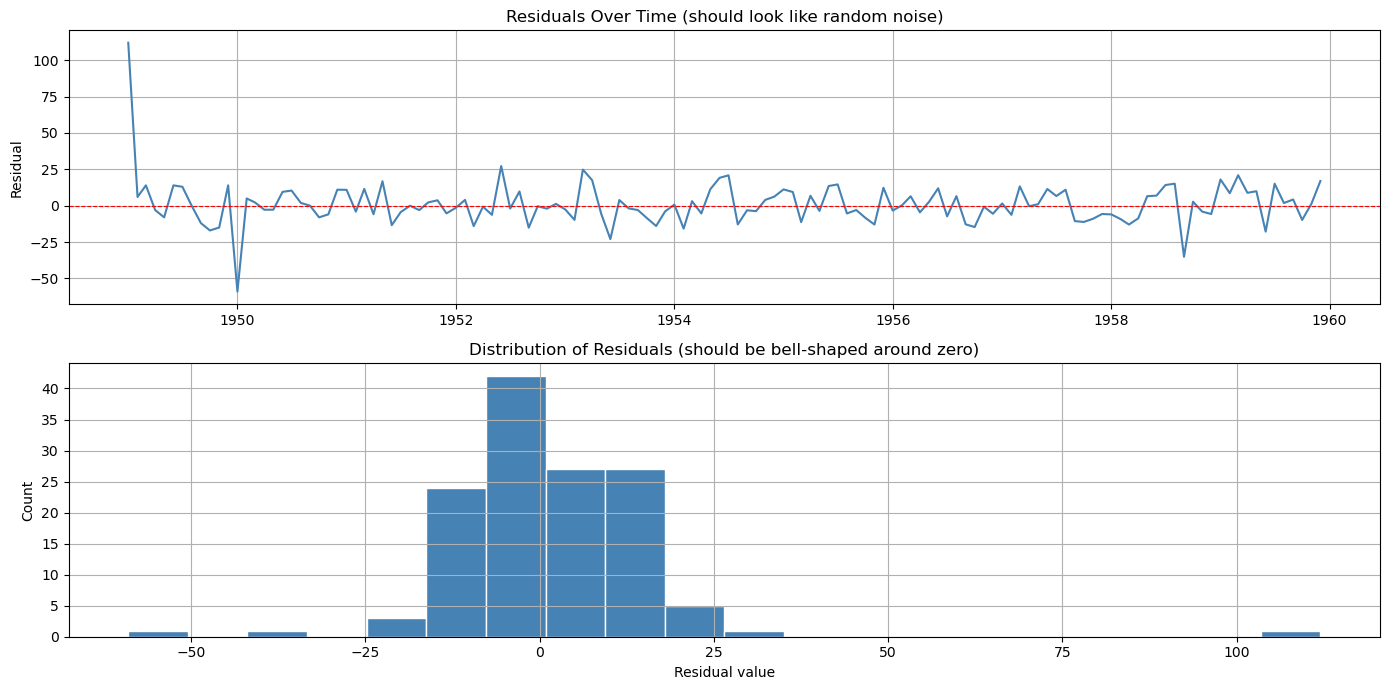

In [ ]:
# Plot the residuals (training errors)

residuals = model_fit.resid

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Residuals over time
axes[0].plot(residuals, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title('Residuals Over Time (should look like random noise)')
axes[0].set_ylabel('Residual')
axes[0].grid(True)

# Histogram of residuals
axes[1].hist(residuals, bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Residuals (should be bell-shaped around zero)')
axes[1].set_xlabel('Residual value')
axes[1].set_ylabel('Count')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# What to look for:
# - Top chart: the line should bounce randomly around zero with no clear trend
# - Bottom chart: the bars should form a rough bell shape centred at zero

---
## Step 13 — Make Predictions and Evaluate

Now we use the trained model to **forecast** the 12 months in our test set.  
We then compare those forecasts to the actual values to see how accurate the model is.

In [ ]:
# Use the model to forecast the 12 months in the test set
# steps=12 means predict 12 months ahead
# exog=test['month'] gives the model the month numbers for those 12 months

predictions = model_fit.forecast(steps=len(test), exog=test['month'])

print("Predictions generated for the test period.")
print()

# Show predicted vs actual side by side
comparison = pd.DataFrame({
    'Actual':    test['Passengers'],
    'Predicted': predictions.values,
    'Error':     test['Passengers'] - predictions.values
})

print("Actual vs Predicted (first 6 months of test period):")
print(comparison.head(6))

Predictions generated for the test period.

Actual vs Predicted (first 6 months of test period):
            Actual   Predicted      Error
1960-01-01     417  424.109830  -7.109830
1960-02-01     391  407.055669 -16.055669
1960-03-01     419  470.825702 -51.825702
1960-04-01     461  460.881615   0.118385
1960-05-01     472  484.868020 -12.868020
1960-06-01     535  536.871326  -1.871326


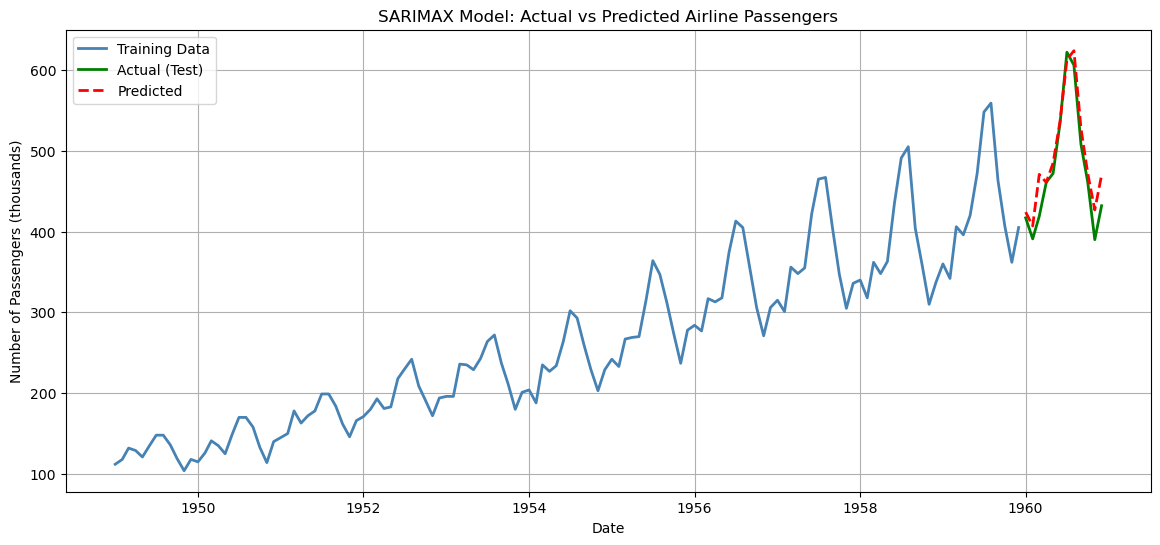

In [ ]:
# Plot actual vs predicted

plt.figure(figsize=(14, 6))

# Training data
plt.plot(train.index, train['Passengers'],
         label='Training Data', color='steelblue', linewidth=2)

# Actual test values
plt.plot(test.index, test['Passengers'],
         label='Actual (Test)', color='green', linewidth=2)

# Predicted values
plt.plot(test.index, predictions,
         label='Predicted', color='red', linewidth=2, linestyle='--')

plt.title('SARIMAX Model: Actual vs Predicted Airline Passengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers (thousands)')
plt.legend()
plt.grid(True)
plt.show()

# Blue  = what the model learned from (training period)
# Green = what actually happened (test period)
# Red   = what the model predicted for the test period

---
### Key concepts to remember

- ARIMA needs **stationary** data — use differencing to achieve this
- Use **ACF** to choose q, and **PACF** to choose p
- Always evaluate on a **test set** the model has never seen
- **Residuals** should look like random noise if the model is good

### What comes next

- Try different parameter combinations
- Apply ARIMA to your own unit sales data from the Feature Engineering notebook